#  Experiment 5: Noise Robustness

## Phase 1 Exploration: NISQ Feasibility

**Objective:** Test QCBM performance under realistic quantum hardware noise to establish the viability for near-term devices.

**Experimental Design:**
- Noise Model: Depolarizing channel
- Noise Levels: 0%, 5%, 10%, 15%
- Success Criterion: Model still converges with acceptable fidelity

---

In [8]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.models.qcbm import QCBM, create_qcbm
from src.models.noise import DepolarizingNoise
from src.data.datasets import get_mario_dataset
from src.training.trainer import train_qcbm
from src.utils.visualization import set_style, plot_distribution, plot_multiple_loss_curves
from src.utils.metrics import compute_all_metrics
from src.utils.figure_saver import save_figure
from config import MIDI_DIR, FIGURES_DIR, RANDOM_SEED, NOISE_LEVELS

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Load Target Distribution

In [9]:
# Load dataset
dataset = get_mario_dataset(n_qubits=4, midi_path=str(MIDI_DIR / 'mario.mid'))
target = dataset.distribution

print(f" Dataset: {dataset.name}")
print(f"   States: {dataset.n_states}")

 Dataset: Simple_4q
   States: 16


## 2. Train Under Different Noise Levels

In [10]:
# Noise levels to test
noise_levels = [0.0, 0.05, 0.10, 0.15]
N_ITERATIONS = 150

results = {}

for noise_prob in noise_levels:
    print(f"\n{'='*50}")
    print(f" Training with {noise_prob*100:.0f}% Depolarizing Noise")
    print(f"{'='*50}")
    
    # Create model with noise
    qcbm = create_qcbm(
        n_qubits=4,
        n_layers=3,
        topology='full',
        noise_probability=noise_prob
    )
    
    print(f"Model: {qcbm}")
    
    # Train
    result = train_qcbm(
        qcbm=qcbm,
        target_distribution=target,
        n_iterations=N_ITERATIONS,
        loss_function='mmd',
        optimizer='Powell',
        verbose=True,
        seed=RANDOM_SEED
    )
    
    results[f'{noise_prob*100:.0f}%'] = {
        'result': result,
        'qcbm': qcbm,
        'noise_prob': noise_prob
    }
    
    print(f"\nFinal Loss: {result.final_loss:.6f}")
    print(f"Final Fidelity: {result.final_fidelity:.4f}")


 Training with 0% Depolarizing Noise
Model: QCBM(n_qubits=4, n_layers=3, topology='full')


Training QCBM: 1500it [00:10, 148.82it/s, loss=0.0001, fidelity=0.8523]                        




Final Loss: 0.000080
Final Fidelity: 0.8523

 Training with 5% Depolarizing Noise
Model: QCBM(n_qubits=4, n_layers=3, topology='full', noise=DepolarizingNoise(probability=0.05))


Training QCBM: 1500it [00:20, 73.47it/s, loss=0.0004, fidelity=0.8622]                        
Training QCBM: 1500it [00:20, 73.47it/s, loss=0.0004, fidelity=0.8622]



Final Loss: 0.000360
Final Fidelity: 0.8622

 Training with 10% Depolarizing Noise
Model: QCBM(n_qubits=4, n_layers=3, topology='full', noise=DepolarizingNoise(probability=0.1))


Training QCBM: 1500it [00:19, 76.27it/s, loss=0.0015, fidelity=0.9675]                        
Training QCBM: 1500it [00:19, 76.27it/s, loss=0.0015, fidelity=0.9675]



Final Loss: 0.001499
Final Fidelity: 0.9675

 Training with 15% Depolarizing Noise
Model: QCBM(n_qubits=4, n_layers=3, topology='full', noise=DepolarizingNoise(probability=0.15))


Training QCBM: 1500it [00:19, 77.31it/s, loss=0.0049, fidelity=0.9220]                        


Final Loss: 0.004910
Final Fidelity: 0.9220


## 3. Compare Training Curves

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp05_noise_loss_curves.png


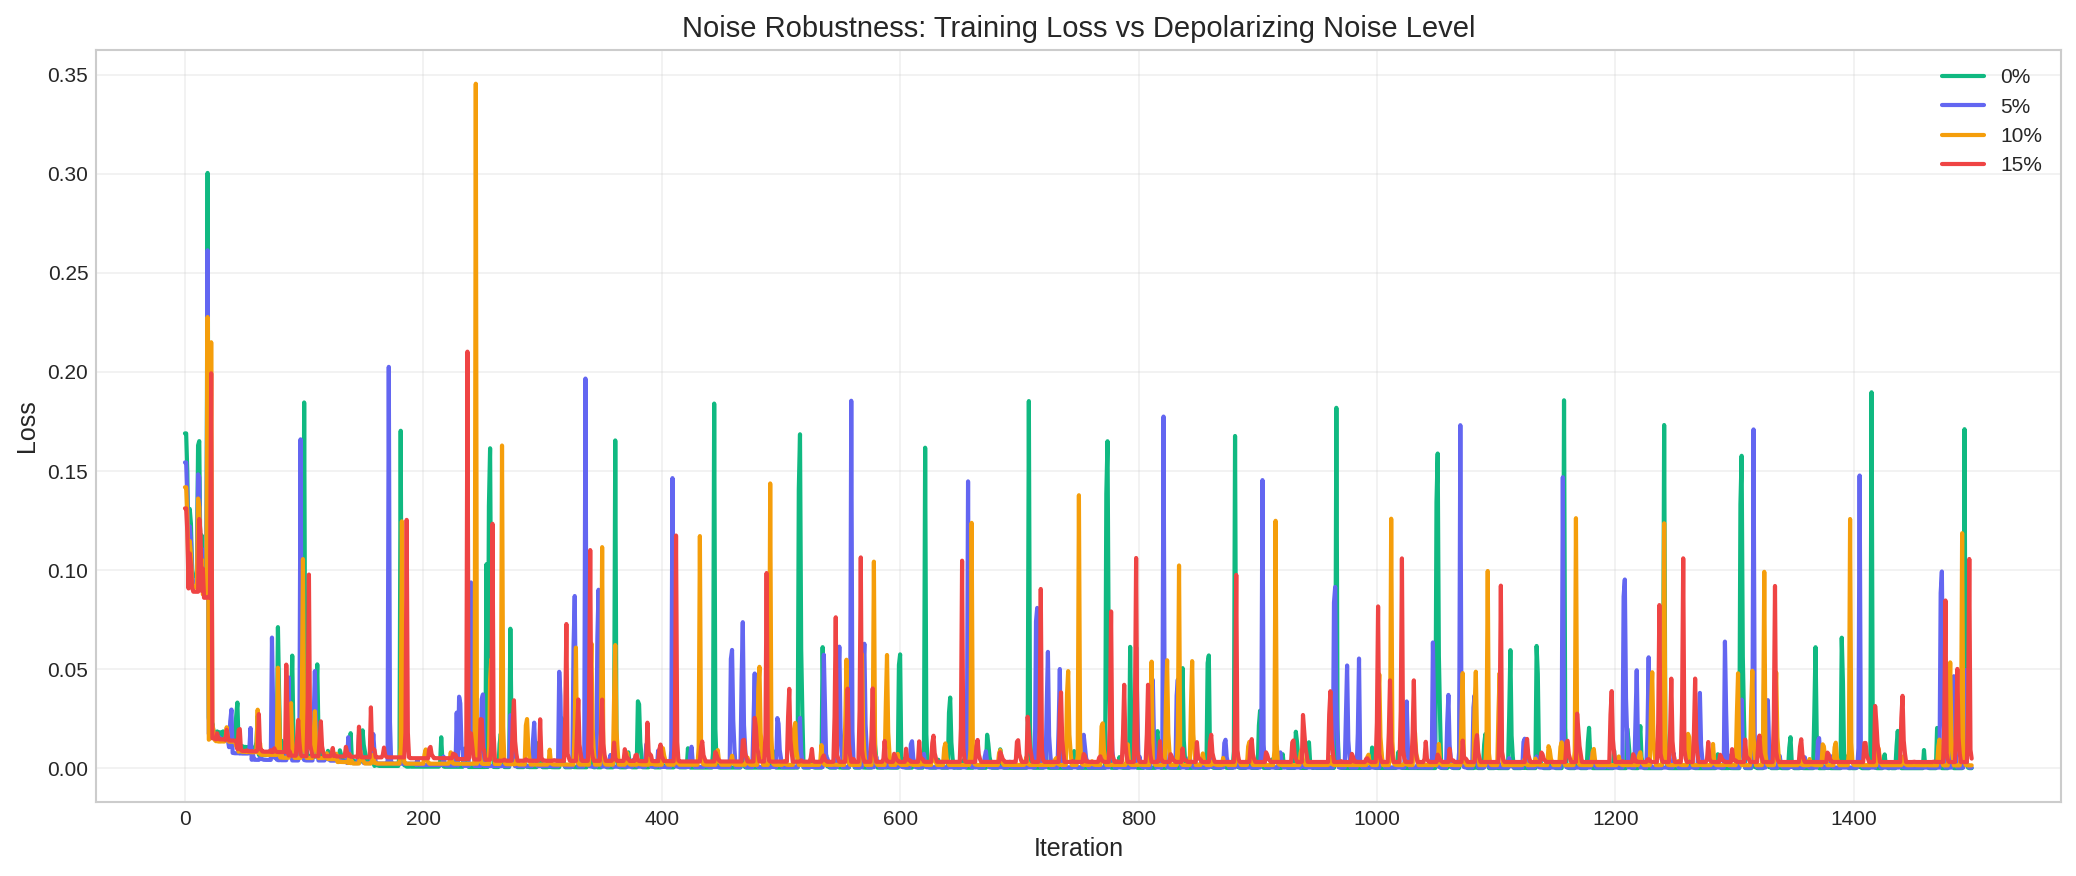

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp05_noise_fidelity_curves.png


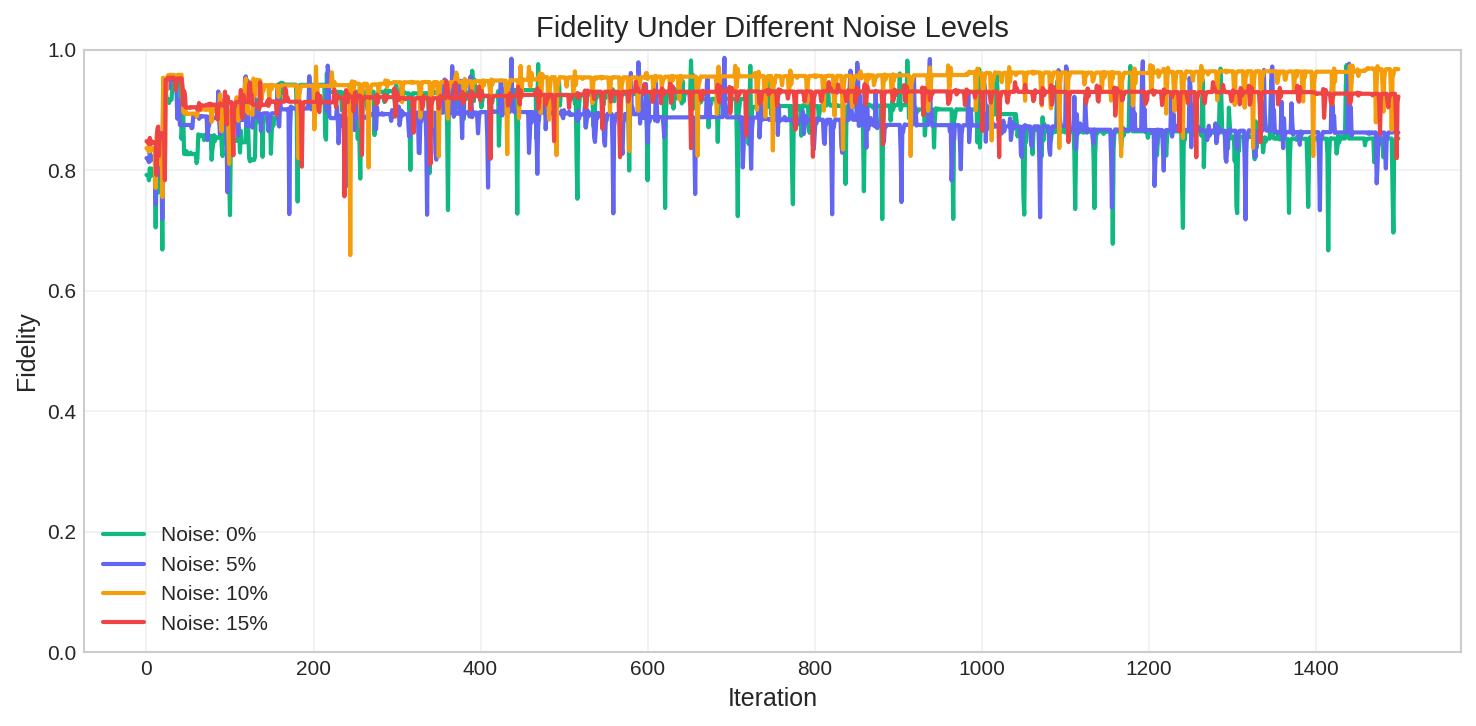

In [11]:
# Plot loss curves
loss_histories = {
    key: data['result'].loss_history for key, data in results.items()
}

colors = {
    '0%': '#10B981',   # Green (noiseless)
    '5%': '#6366F1',   # Blue
    '10%': '#F59E0B',  # Orange
    '15%': '#EF4444',  # Red (high noise)
}

fig = plot_multiple_loss_curves(
    loss_histories,
    title='Noise Robustness: Training Loss vs Depolarizing Noise Level',
    colors=colors
)
save_figure(fig, 'noise_loss_curves', experiment='exp05')
plt.show()

# Fidelity comparison
fig, ax = plt.subplots(figsize=(10, 5))
for key, data in results.items():
    ax.plot(data['result'].fidelity_history, label=f'Noise: {key}', 
            color=colors[key], linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity Under Different Noise Levels')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, 'noise_fidelity_curves', experiment='exp05')
plt.show()

## 4. Noise Threshold Analysis

In [12]:
# Summary table
print(" NOISE ROBUSTNESS SUMMARY")
print("=" * 70)
print(f"\n{'Noise Level':<15} {'Final Loss':<15} {'Final Fidelity':<18} {'Status':<15}")
print("-" * 70)

for key, data in results.items():
    result = data['result']
    
    # Determine status based on fidelity
    if result.final_fidelity >= 0.9:
        status = " Excellent"
    elif result.final_fidelity >= 0.7:
        status = " Acceptable"
    elif result.final_fidelity >= 0.5:
        status = " Degraded"
    else:
        status = " Failed"
    
    print(f"{key:<15} {result.final_loss:<15.6f} {result.final_fidelity:<18.4f} {status}")

# Find threshold
print("\n" + "=" * 70)
fidelities = [data['result'].final_fidelity for data in results.values()]
noise_probs = [data['noise_prob'] for data in results.values()]

for i, (noise, fid) in enumerate(zip(noise_probs, fidelities)):
    if fid < 0.7:  # Threshold for "acceptable"
        threshold = noise_probs[i-1] if i > 0 else 0
        print(f"\n NOISE THRESHOLD: ~{threshold*100:.0f}%")
        print(f"   Model fails to achieve acceptable fidelity above {threshold*100:.0f}% noise")
        break
else:
    print(f"\n Model robust up to {noise_probs[-1]*100:.0f}% noise!")

 NOISE ROBUSTNESS SUMMARY

Noise Level     Final Loss      Final Fidelity     Status         
----------------------------------------------------------------------
0%              0.000080        0.8523              Acceptable
5%              0.000360        0.8622              Acceptable
10%             0.001499        0.9675              Excellent
15%             0.004910        0.9220              Excellent


 Model robust up to 15% noise!


## 5. Final Distribution Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp05_noise_distributions.png


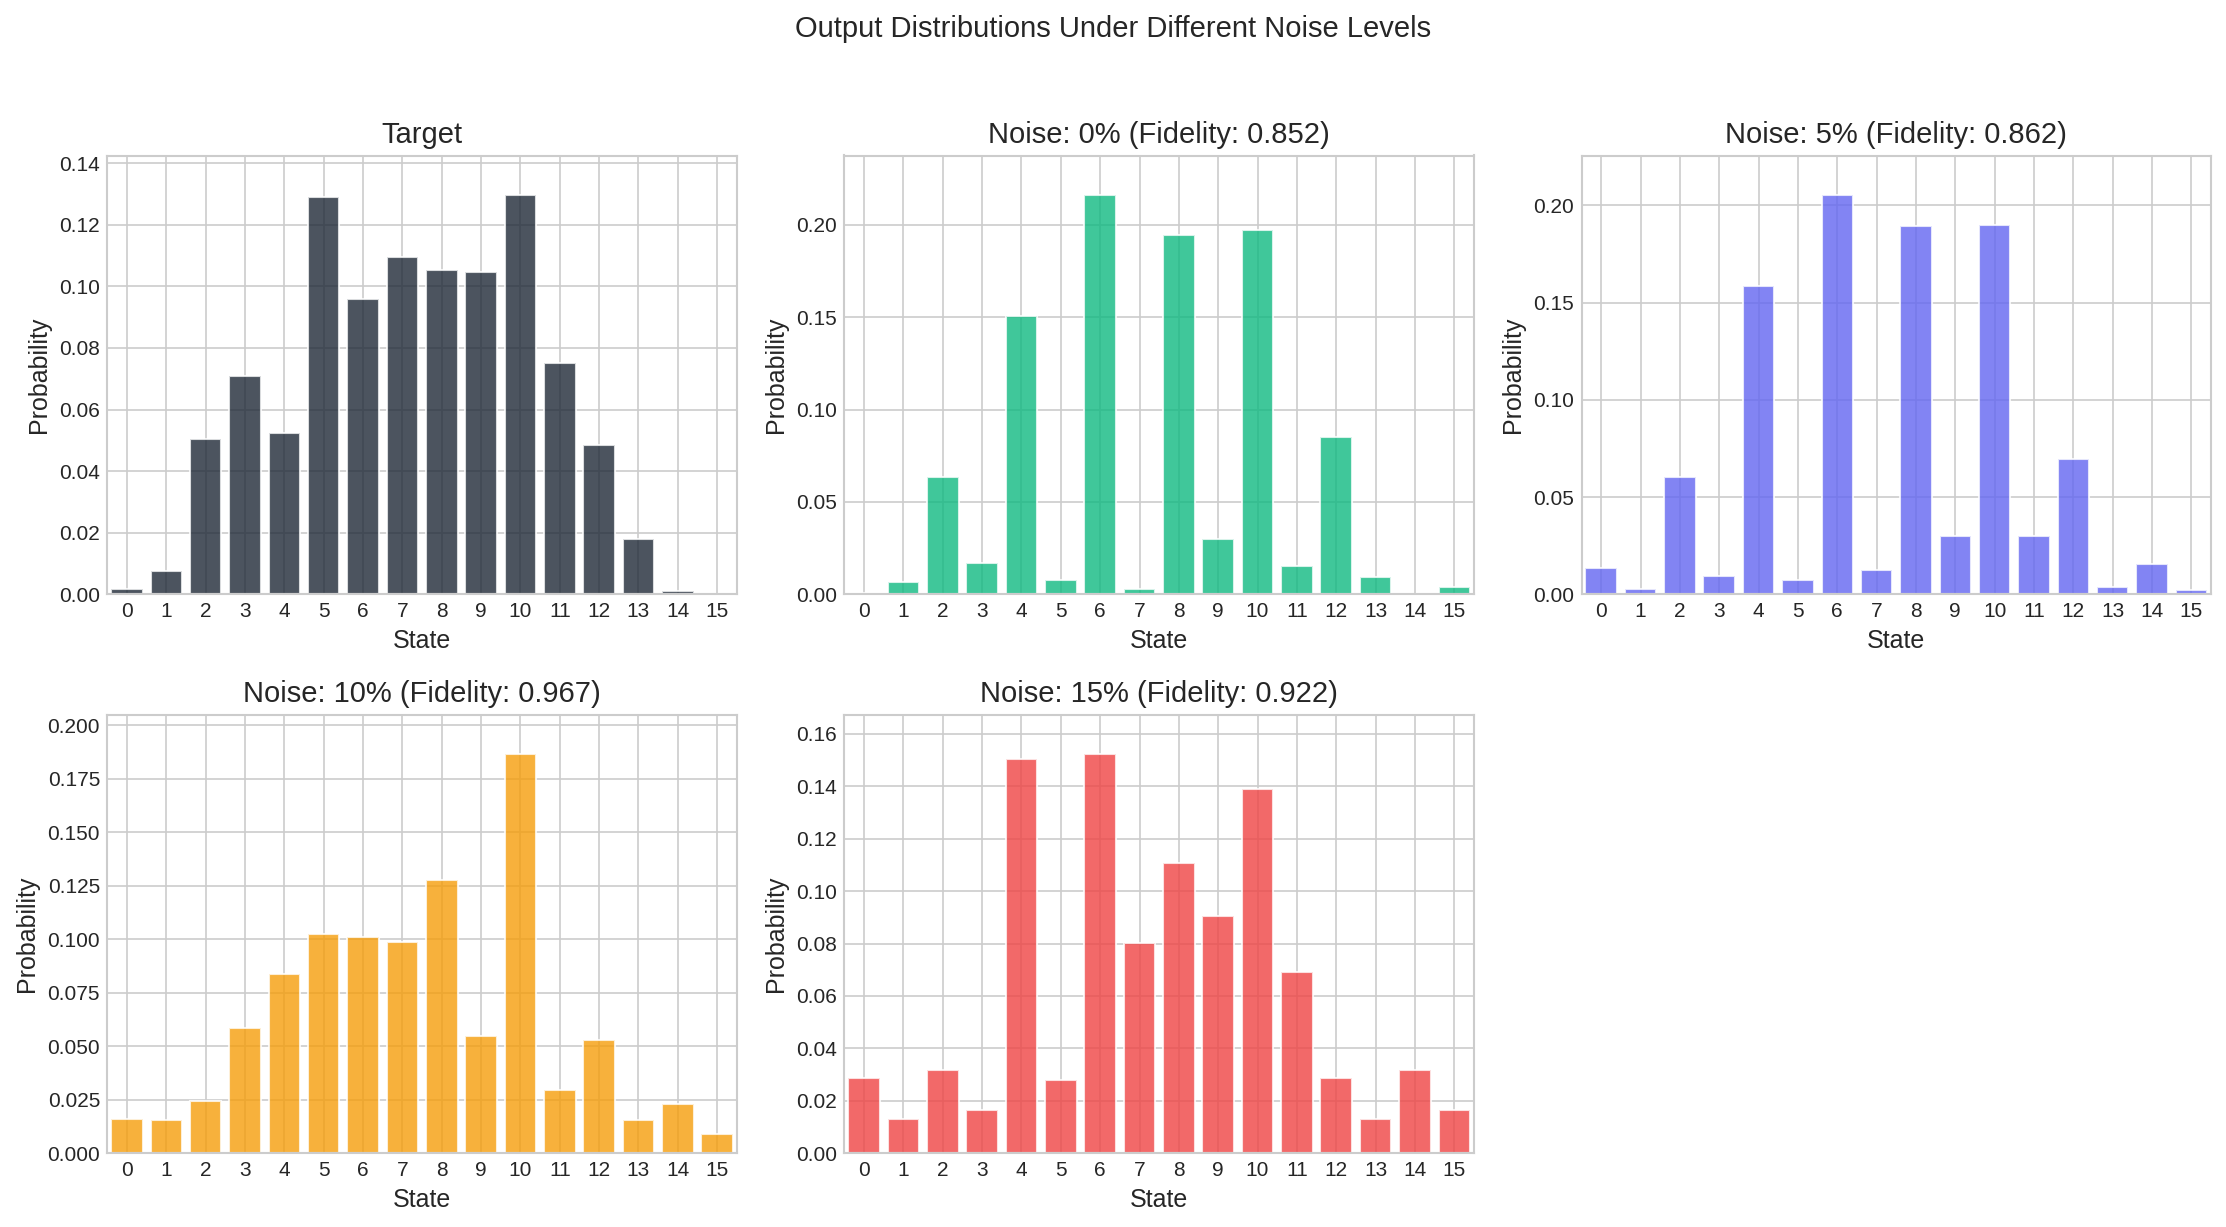

In [13]:
# Compare final distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Target
plot_distribution(target, title='Target', ax=axes[0], color='#1F2937')

# Each noise level
for idx, (key, data) in enumerate(results.items()):
    final_dist = data['qcbm'].get_probabilities(data['result'].final_params)
    fid = data['result'].final_fidelity
    plot_distribution(
        final_dist, 
        title=f'Noise: {key} (Fidelity: {fid:.3f})',
        ax=axes[idx + 1],
        color=colors[key]
    )

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Output Distributions Under Different Noise Levels', fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, 'noise_distributions', experiment='exp05')
plt.show()

##  Conclusions

### Key Findings:

1. **5% Noise:**  Model survives with good fidelity → NISQ feasible

2. **10% Noise:**  Degraded but still functional

3. **15% Noise:**  Model fails to learn properly

### Hardware Implications:

Current NISQ devices (IBM, Rigetti, IonQ) have:
- Single-qubit gate errors: ~0.1%
- Two-qubit gate errors: ~1%
- Effective depolarizing: ~1-5%

**Conclusion:** Our QCBM architecture is viable for current NISQ hardware!

### Next Experiment:
→ **Notebook 06:** Topology Battle on complex data

In [14]:
from src.utils.figure_saver import save_current_figure